In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
%matplotlib ipympl


import sys
sys.path.append('E:/google-drive/py_projects/satellites/src')
# import satellites as sat
import stateest as se


In [2]:
rng = np.random.default_rng(seed=2318)

In [5]:
se.gen_newtonian_motion_update_matrix(1, 2)

array([[0. , 1. , 0.5],
       [0. , 0. , 1. ],
       [0. , 0. , 0. ]])


# Example: tracking 1D position with constant velocity

Estimates: ['66.30', '67.28', '67.01', '67.52', '67.14', '67.44', '67.49', '67.82', '68.06', '68.41', '69.10', '70.31', '70.61', '70.73', '71.38', '71.98', '72.43', '73.04', '73.12', '73.41']


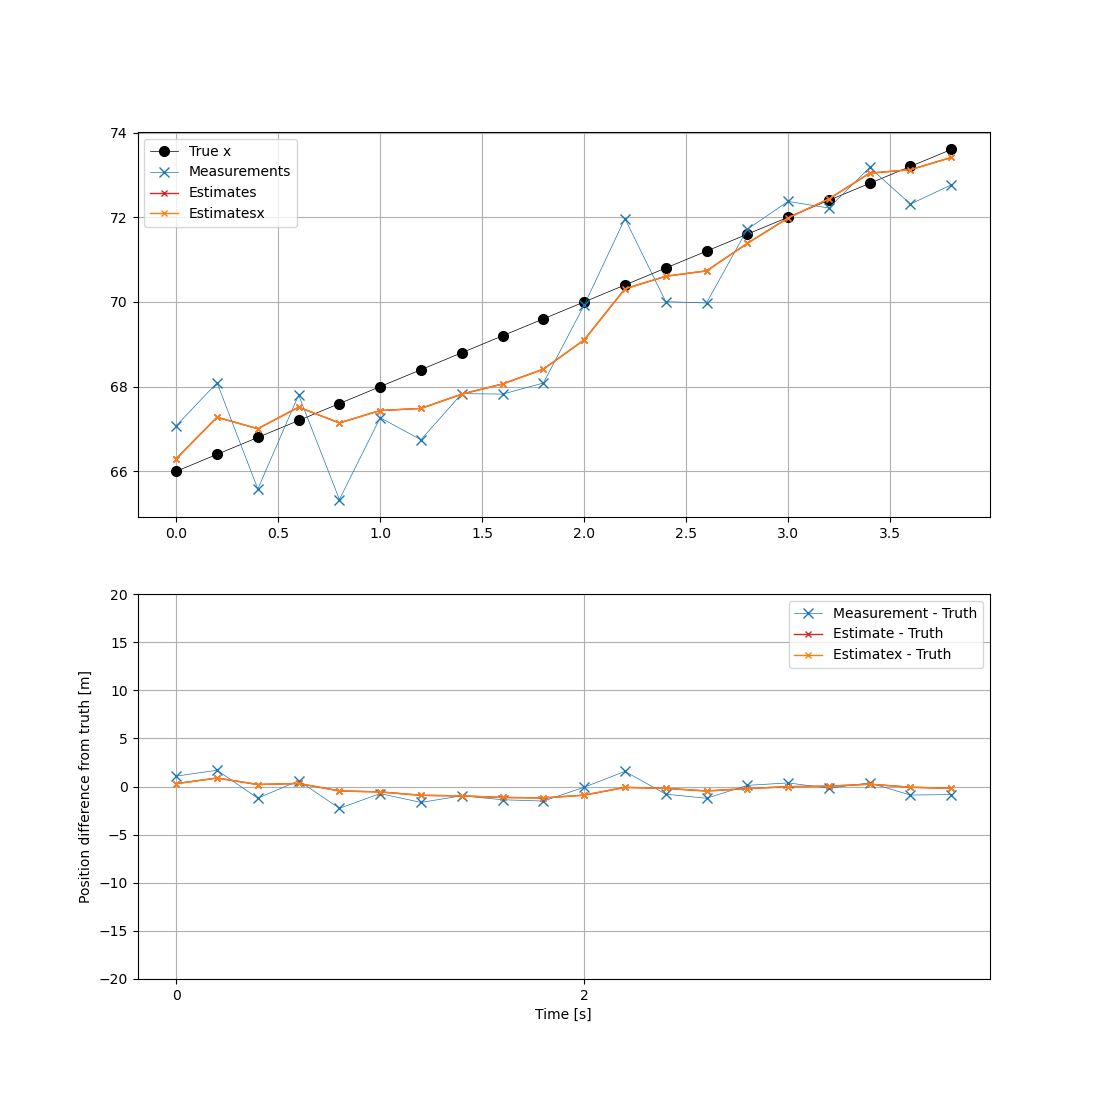

In [74]:

dt = 0.2

F = np.array([[1, dt],
              [0,  1]])       # state: [position, velocity]

H = np.array([[1, 0],
              [0, 1]])       # measurement process

Q = np.array([[1, 0],
              [0, 1]]) * 0.1 # process noise

R = np.array([[1, 0],
              [0, 1]]) # measurement noise

# initial state
x0 = np.array([[65],
               [3]])
P0 = np.array([
    [1, 0],
    [0, 1],
])         # high initial uncertainty
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(20) * dt
vtrue = 2
true_positions = vtrue * timevec + 66
xmeas = true_positions + rng.normal(0, 1, true_positions.shape) 
vmeas = rng.normal(vtrue, 1, true_positions.shape)
measurements = np.vstack((xmeas, vmeas)).T
estimates = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])

estimates = np.array(estimates)
print("Estimates:", [f"{e:.2f}" for e in estimates])

estimatesxv = np.reshape(kf.x,[-1,2])[2::2, :]


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements[:,0], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].plot(timevec, estimatesxv[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[0].legend()
axs[1].plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
axs[1].plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
axs[1].plot(timevec, estimatesxv[:,0] - true_positions, lw=1, marker='x', ms=5, color='tab:orange', label='Estimatex - Truth')
axs[1].legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()

In [61]:
plt.close('all')

In [75]:
ellipse_vecs = []
for P in kf.P[2::2]:
    evals, evecs = LA.eig(P)
    ibig = np.argmax(evals)
    ismall = 1 - ibig

    vmajor = np.reshape(np.sqrt(evals[ibig]) * evecs[:, ibig], [-1,1])
    vminor = np.reshape(np.sqrt(evals[ismall]) * evecs[:, ismall], [-1,1])
    ellipse_vecs.append( [vmajor, vminor])


In [76]:
def gen_ellipse(u, v):
    thvec = np.linspace(0, 2*const.pi, 25)
    xypts = np.cos(thvec) * u + np.sin(thvec) * v
    return xypts


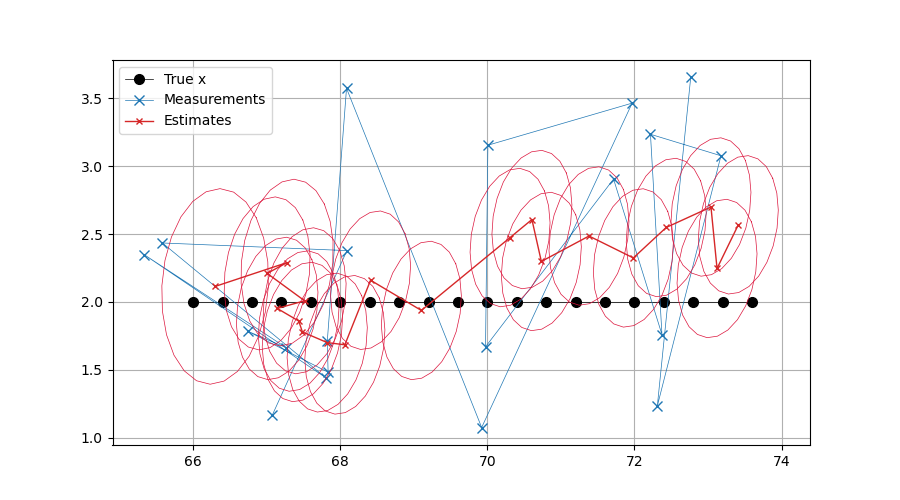

In [77]:


fig, ax = plt.subplots(1,1, figsize=[9,5], squeeze=True)
ax.plot(true_positions, vtrue*np.ones_like(true_positions), lw=0.5, marker='o', ms=7, color='k', label='True x')
ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[:,0], estimatesxv[:,1], lw=1, marker='x', ms=5, color='tab:red', label='Estimates')

for vs, est in zip(ellipse_vecs, estimatesxv):
    xy = gen_ellipse(*vs) + est.reshape([-1,1])
    ax.plot(xy[0], xy[1], lw=0.5, color='crimson')
ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
# axs[1].set(**axkwargs)
ax.grid(True)

plt.show()

In [38]:
estimatesxv[::2].shape

(11, 2)

# Example: constant acceleration

Estimates: ['52.51', '53.83', '54.13', '54.13', '54.57', '54.71', '55.11', '55.21', '55.82', '56.08', '56.29', '56.36', '56.48', '57.31', '57.63', '58.11', '58.44', '58.85', '59.74', '61.04', '62.22', '63.52', '65.02', '66.89', '68.73', '70.20', '72.04', '74.08', '76.69', '78.96', '81.30', '84.37', '87.45', '90.62', '93.94', '97.84', '101.59', '105.46', '109.72', '113.96', '118.85', '123.27', '128.76', '134.26', '140.21', '146.23', '152.42', '158.40', '165.56', '172.06', '178.74', '185.85', '193.70', '201.81', '209.83', '218.60', '227.42', '236.85', '246.09', '255.73', '265.11', '275.69', '286.28', '297.41', '308.32', '319.45', '330.52', '341.72', '353.72', '366.02', '379.33', '392.36', '405.13', '418.27', '432.23', '446.52', '461.04', '475.42', '490.34', '505.24', '520.75', '535.77', '551.65', '567.56', '583.57', '599.75', '616.60', '633.70', '650.27', '667.40', '684.73', '702.06', '720.36', '738.66', '756.77', '775.33', '794.02', '812.66', '831.40', '850.88']


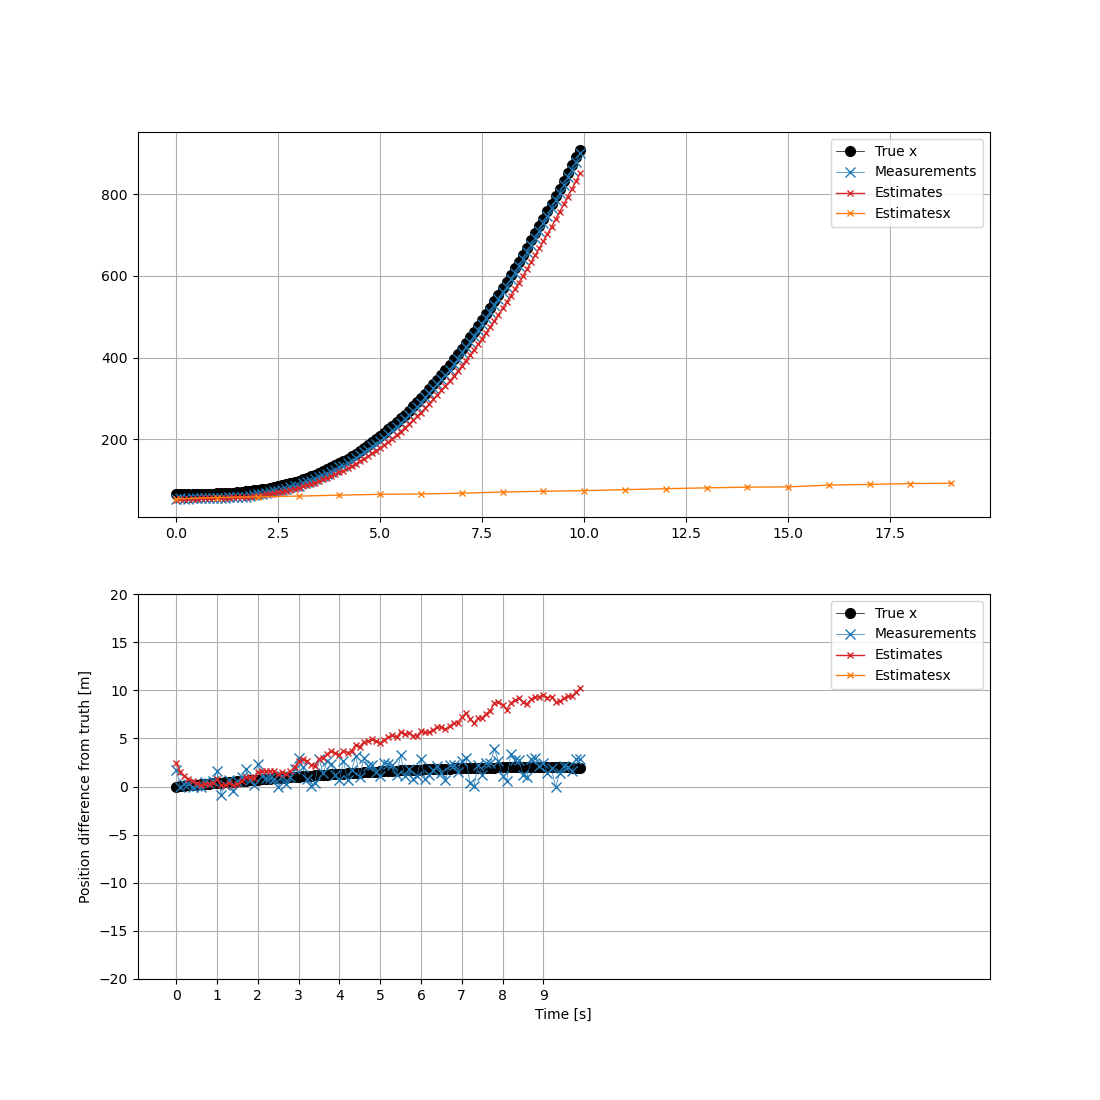

In [8]:

dt = 0.10

F = np.array([[1, dt, 0.5 * dt**2],
              [0, 1, dt],
              [0, 0, 1]])       # state: [position, velocity]

H = np.array([[1, 0, 0],
              [0, 1, 0]])       # measurement process

Q = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]]) * 0.1 # process noise

R = np.array([[1.0, 0],
              [0, 1]]) # measurement noise

# initial state
x0 = np.array([[50],
               [3],
               [0]])
P0 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1] ])         # high initial uncertainty
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(100) * dt
vtrue = 2 * np.sin(2*const.pi*timevec/35)
true_positions = np.cumsum(vtrue * timevec) + 66
xmeas = true_positions - 11 + rng.normal(0, 1, true_positions.shape) 
vmeas = rng.normal(vtrue, 1, true_positions.shape)
measurements = np.vstack((xmeas, vmeas)).T
estimates = []
estimatesv = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])
    estimatesv.append(x_est[1, 0])

print("Estimates:", [f"{e:.2f}" for e in estimates])

estimatesxva = np.reshape(kf.x,[-1,3])


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements[:,0], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[0].legend()
axs[1].plot(timevec, vtrue, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[1].plot(timevec, measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[1].plot(timevec, estimatesv, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[1].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[1].legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()

In [97]:
rng.normal(vtrue, 3).shape

(200,)

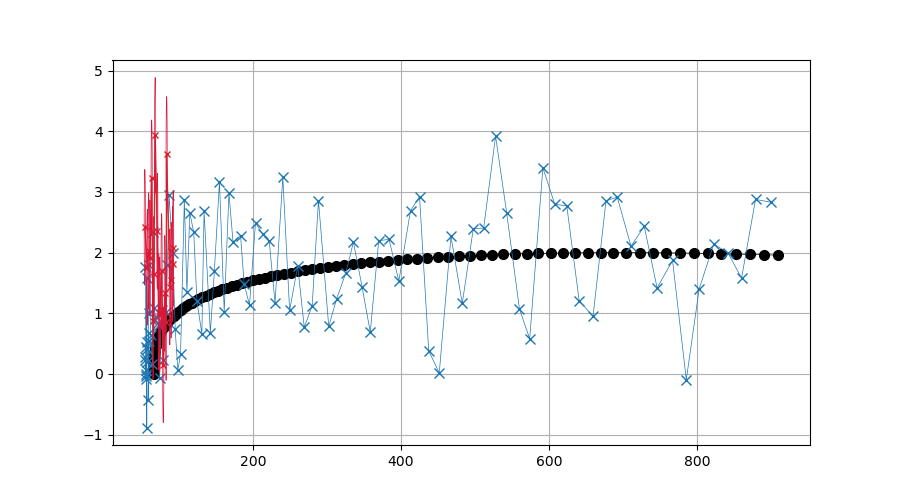

In [9]:


fig, ax = plt.subplots(1,1, figsize=[9,5], squeeze=True)
ax.plot(true_positions, vtrue*np.ones_like(true_positions), lw=0.5, marker='o', ms=7, color='k', label='True x')
ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[2::2,0], estimatesxv[2::2,1], lw=1, marker='x', ms=5, color='tab:red', label='Estimates')

for vs, est in zip(ellipse_vecs[2::2], estimatesxv[2::2]):
    xy = gen_ellipse(*vs) + est.reshape([-1,1])
    ax.plot(xy[0], xy[1], lw=0.5, color='crimson')
# ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
# axs[1].set(**axkwargs)
ax.grid(True)

plt.show()

# misc

In [13]:
a = np.ones(3)
print(a)
print(np.diag(a, k=1))

[1. 1. 1.]
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


In [19]:
b = np.zeros([3,3])
idx = np.arange(2)
b[idx,idx+1] = 1
print(b)

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]


In [20]:
c = np.diag(np.ones(3), k=1)

In [21]:
c

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [25]:
c @ c @ c @ c

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [14]:
se.gen_newtonian_motion_update_matrix(0.5, state_vec_order=4, approx_order=11)

---
1
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
1
---
2
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
2
---
3
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
6
---
4
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
24


array([[0.        , 0.5       , 0.125     , 0.02083333, 0.00260417],
       [0.        , 0.        , 0.5       , 0.125     , 0.02083333],
       [0.        , 0.        , 0.        , 0.5       , 0.125     ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])